# Check tuned runs

In [1]:
import xarray as xr
from matplotlib import pyplot as plt
import os

In [2]:
#exp = 'tu7b'
#exp = 'T009'
exp = 'n000'
cart = f'/ec/res4/scratch/ecme3038/ece4/{exp}/output/oifs/'
filz = cart + f'{exp}_atm_cmip6_1m_*.nc'

In [3]:
gigi = xr.open_mfdataset(filz)

/etc/ecmwf/ssd/ssd1/tmpdirs/ecme3038.2266773.20251110_073539.767/ipykernel_3918664/2052611029.py:1: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  gigi = xr.open_mfdataset(filz)


In [4]:
gigi

<xarray.Dataset> Size: 141MB
Dimensions:               (time_counter: 120, cell: 6114, nvertex: 4,
                           axis_nbounds: 2)
Coordinates:
    lat                   (cell) float32 24kB dask.array<chunksize=(6114,), meta=np.ndarray>
    lon                   (cell) float32 24kB dask.array<chunksize=(6114,), meta=np.ndarray>
    time_centered         (time_counter) datetime64[ns] 960B dask.array<chunksize=(1,), meta=np.ndarray>
  * time_counter          (time_counter) datetime64[ns] 960B 1990-01-16T12:00...
Dimensions without coordinates: cell, nvertex, axis_nbounds
Data variables: (12/44)
    bounds_lon            (time_counter, cell, nvertex) float32 12MB dask.array<chunksize=(12, 6114, 4), meta=np.ndarray>
    bounds_lat            (time_counter, cell, nvertex) float32 12MB dask.array<chunksize=(12, 6114, 4), meta=np.ndarray>
    time_centered_bounds  (time_counter, axis_nbounds) datetime64[ns] 2kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    time_counter_bounds   (time_counter, axis_nbounds) datetime64[ns] 2kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    tas                   (time_counter, cell) float32 3MB dask.array<chunksize=(1, 6114), meta=np.ndarray>
    tasmin                (time_counter, cell) float32 3MB dask.array<chunksize=(1, 6114), meta=np.ndarray>
    ...                    ...
    cll                   (time_counter, cell) float32 3MB dask.array<chunksize=(1, 6114), meta=np.ndarray>
    alb                   (time_counter, cell) float32 3MB dask.array<chunksize=(1, 6114), meta=np.ndarray>
    rnf                   (time_counter, cell) float32 3MB dask.array<chunksize=(1, 6114), meta=np.ndarray>
    sro                   (time_counter, cell) float32 3MB dask.array<chunksize=(1, 6114), meta=np.ndarray>
    ssro                  (time_counter, cell) float32 3MB dask.array<chunksize=(1, 6114), meta=np.ndarray>
    sd                    (time_counter, cell) float32 3MB dask.array<chunksize=(1, 6114), meta=np.ndarray>
Attributes:
    name:         output/oifs/n000_atm_cmip6_1m
    description:  ECE4/OIFS monthly surface fields
    title:        ECE4/OIFS monthly surface fields
    Conventions:  CF-1.6
    timeStamp:    2025-Oct-17 10:20:38 GMT
    uuid:         7b4f5cff-8fc5-43a6-b2dc-12a313d685fa

In [5]:
import numpy as np

In [6]:
gigi = gigi.rename({'time_counter': 'time'})

In [7]:
# Force lat into memory, drop Dask chunking
gigi = gigi.assign_coords(lat=gigi.lat.compute())

# Now your old workflow works
all_lats = gigi.lat.groupby('lat').mean()
weights = np.cos(np.deg2rad(all_lats))

gigimean = (
    gigi.groupby('time.year').mean()
        .groupby('lat').mean()
        .weighted(weights).mean('lat')
)

gigimean = gigimean[['rsut', 'rlut', 'rsdt', 'tas']]
gigimean['toa_net'] = gigimean.rsdt - gigimean.rlut - gigimean.rsut
gigimean = gigimean.compute()

In [8]:
%matplotlib inline

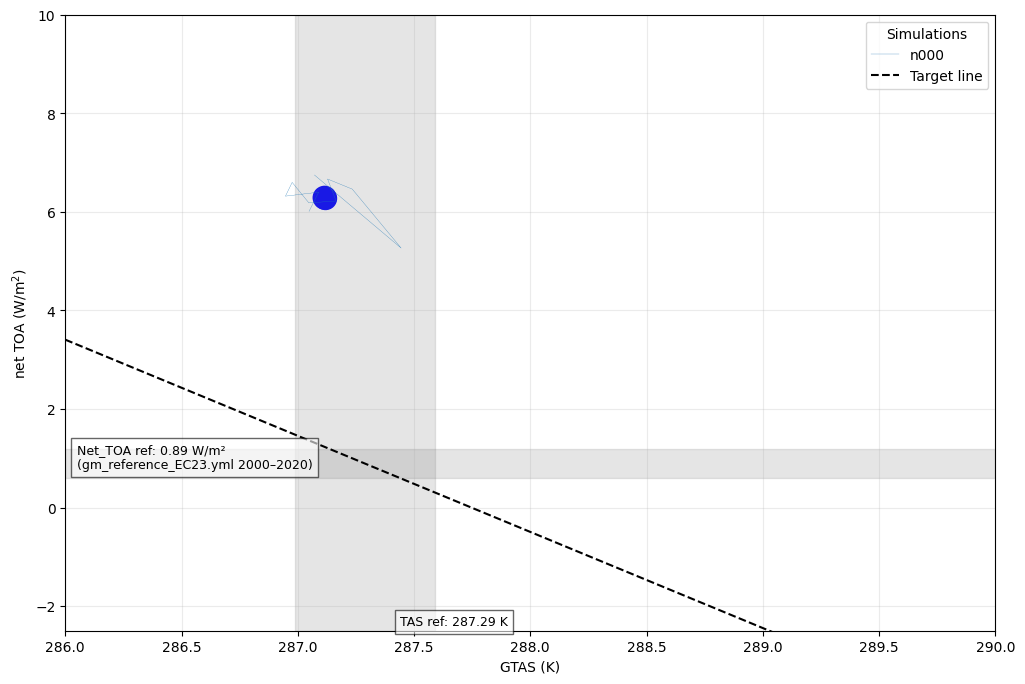

In [9]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(gigimean.tas, gigimean.toa_net, linewidth=0.2, label = 'n000')

tas_clim = 287.29 #from era5 (1990-2000) 287.52 K 1990-2020
net_toa_clim = 0.89 #stima: da Allan et al. (2014) 0.34±0.67W/m-2 periodo 1985-1999, mentre da IPCC 0.50 [0.32 to 0.69] W m–2 periodo 1971–2006
#imbalance?????
dx = dy = 0.3
running20_tas = gigimean.tas.rolling(year=20, center=True).mean()
running20_toa = gigimean.toa_net.rolling(year=20, center=True).mean()
ax.plot(running20_tas, running20_toa, color='blue', linewidth=2.0, linestyle="-")

# --- Marker iniziale/finale ---
ax.set_ylim(-2.5, 10) 
ax.set_xlim(286, 290)
year_min = int(gigimean.tas.year.min())
year_max = int(gigimean.tas.year.max())
init_slice = slice(year_min, min(year_min + 9, year_max))
final_slice = slice(max(year_min, year_max - 9), year_max)

init_tas = gigimean.tas.sel(year=init_slice).mean().item()
init_toa = gigimean.toa_net.sel(year=init_slice).mean().item()
final_tas = gigimean.tas.sel(year=final_slice).mean().item()
final_toa = gigimean.toa_net.sel(year=final_slice).mean().item()

ax.scatter(init_tas, init_toa, s=250, edgecolors="blue", facecolors="none",
           marker="o", linewidth=1.5)
ax.scatter(final_tas, final_toa, s=250, color="blue", edgecolors="blue",
           marker="o", linewidth=1.0)

# --- Fit e linea target (solo dal primo esperimento) ---
slope, intercept = np.polyfit(gigimean.tas.values, gigimean.toa_net.values, 1)
# xmin, xmax = float(gigimean.tas.min()), float(gigimean.tas.max())
# ymin, ymax = float(gigimean.toa_net.min()), float(gigimean.toa_net.max())
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
x_line = np.linspace(xmin, xmax, 200)
y_line = slope * (x_line - tas_clim) + net_toa_clim
ax.plot(x_line, y_line, "k--", label="Target line")

# =====================================================================
# === BANDE DI RIFERIMENTO E TESTO ====================================
# =====================================================================

ax.fill_betweenx(np.linspace(ymin, ymax, 200),
                 tas_clim - dx, tas_clim + dx, color="grey", alpha=0.2)
ax.fill_between(np.linspace(xmin, xmax, 200),
                net_toa_clim - dy, net_toa_clim + dy, color="grey", alpha=0.2)

x_text_tas = tas_clim + dx / 2
y_text_tas = ymin + 0.05  
ax.text(x_text_tas, y_text_tas, f"TAS ref: {tas_clim:.2f} K",
        va="bottom", ha="left", fontsize=9,
        bbox=dict(facecolor="white", alpha=0.6))

x_text_toa = xmin + 0.05
y_text_toa = net_toa_clim - dy / 2
ax.text(x_text_toa, y_text_toa,
        f"Net_TOA ref: {net_toa_clim:.2f} W/m²\n(gm_reference_EC23.yml 2000–2020)",
        va="bottom", ha="left", fontsize=9,
        bbox=dict(facecolor="white", alpha=0.6))


ax.set_xlabel("GTAS (K)")
ax.set_ylabel("net TOA (W/m$^2$)")
ax.grid(alpha=0.25)
ax.legend(title="Simulations", loc="best")

# out_dir = "/home/ecme3038/work/ecearth/ecearth4/ECtuner/plots"
# os.makedirs(out_dir, exist_ok=True)
# outname = os.path.join(out_dir, "greg_tu7b.png")
# plt.savefig(outname, dpi=200, bbox_inches="tight")
# print("Saved plot to:", outname)
# plt.close(fig)


In [10]:
green_tas = gigimean.tas.sel(year=slice(2090, 2099)).mean().item()
print(green_tas)

nan


### Adding new run (should decrease gtas)

In [11]:
#exp = 'TN13'
exp = 'mnt1'
cart = f'/ec/res4/scratch/ecme3038/ece4/{exp}/output/oifs/'
filz = cart + f'{exp}_atm_cmip6_1m_*.nc'

In [12]:
gigi2 = xr.open_mfdataset(filz)

/etc/ecmwf/ssd/ssd1/tmpdirs/ecme3038.2266773.20251110_073539.767/ipykernel_3918664/2681663377.py:1: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  gigi2 = xr.open_mfdataset(filz)


In [13]:
gigi2 = gigi2.rename({'time_counter': 'time'})

In [14]:
# Force lat into memory, drop Dask chunking
gigi2 = gigi2.assign_coords(lat=gigi2.lat.compute())

all_lats = gigi2.lat.groupby('lat').mean()
weights = np.cos(np.deg2rad(all_lats))

gigimean2 = (
    gigi2.groupby('time.year').mean()
        .groupby('lat').mean()
        .weighted(weights).mean('lat')
)

gigimean2 = gigimean2[['rsut', 'rlut', 'rsdt', 'tas']]
gigimean2['toa_net'] = gigimean2.rsdt - gigimean2.rlut - gigimean2.rsut
gigimean2 = gigimean2.compute()

In [15]:
ax.plot(gigimean2.tas, gigimean2.toa_net, color = 'orange', linewidth=0.2, label='mnt1')
running20_tas = gigimean2.tas.rolling(year=20, center=True).mean()
running20_toa = gigimean2.toa_net.rolling(year=20, center=True).mean()
ax.plot(running20_tas, running20_toa, color='orange', linewidth=2.0)

year_min = int(gigimean2.tas.year.min())
year_max = int(gigimean2.tas.year.max())
init_slice = slice(year_min, min(year_min + 9, year_max))
final_slice = slice(max(year_min, year_max - 9), year_max)
init_tas = gigimean2.tas.sel(year=init_slice).mean().item()
init_toa = gigimean2.toa_net.sel(year=init_slice).mean().item()
final_tas = gigimean2.tas.sel(year=final_slice).mean().item()
final_toa = gigimean2.toa_net.sel(year=final_slice).mean().item()
ax.scatter(init_tas, init_toa, s=250, edgecolors="orange", facecolors="none",
           marker="o", linewidth=1.5)
ax.scatter(final_tas, final_toa, s=250, color='orange', edgecolors="orange",
           marker="o", linewidth=1.0)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title="Simulations", loc="best")

# out_dir = "/home/ecme3038/work/ecearth/ecearth4/ECtuner/plots"
# os.makedirs(out_dir, exist_ok=True)
# outname = os.path.join(out_dir, "greg_tu7b_t7m3.png")
# plt.savefig(outname, dpi=200, bbox_inches="tight")
# print("Saved plot to:", outname)
# plt.close(fig)

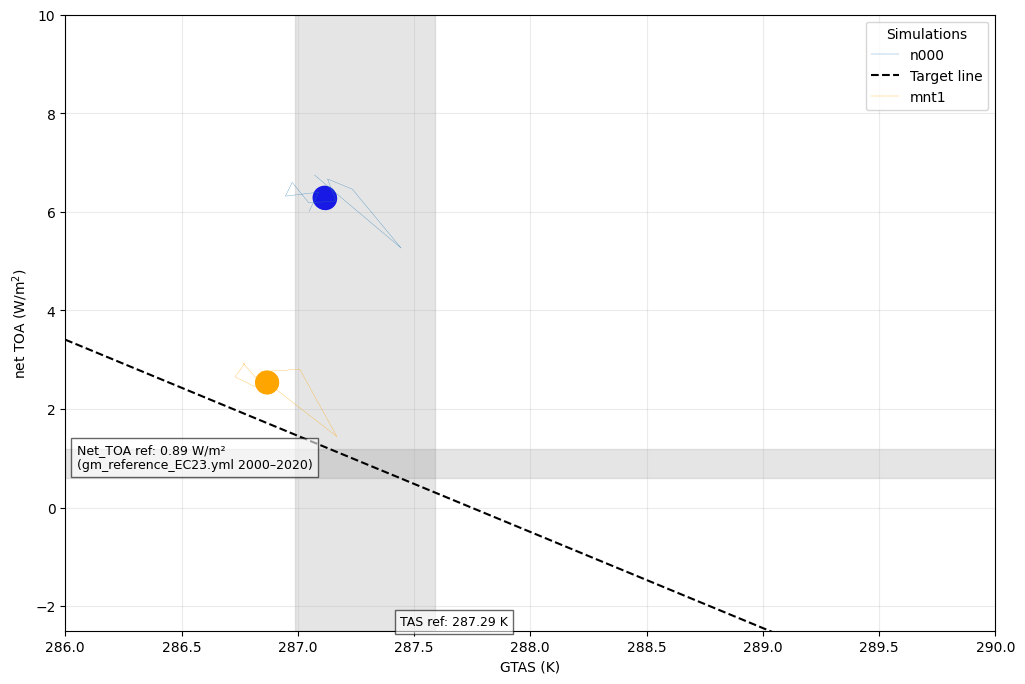

In [16]:
fig

In [17]:
#exp = 'TN14'
exp = 'mnt2'
cart = f'/ec/res4/scratch/ecme3038/ece4/{exp}/output/oifs/'
filz = cart + f'{exp}_atm_cmip6_1m_*.nc'

In [18]:
gigi3 = xr.open_mfdataset(filz)

/etc/ecmwf/ssd/ssd1/tmpdirs/ecme3038.2266773.20251110_073539.767/ipykernel_3918664/2167125097.py:1: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  gigi3 = xr.open_mfdataset(filz)


In [19]:
gigi3 = gigi3.rename({'time_counter': 'time'})

In [20]:
# Force lat into memory, drop Dask chunking
gigi3 = gigi3.assign_coords(lat=gigi3.lat.compute())

all_lats = gigi3.lat.groupby('lat').mean()
weights = np.cos(np.deg2rad(all_lats))

gigimean3 = (
    gigi3.groupby('time.year').mean()
        .groupby('lat').mean()
        .weighted(weights).mean('lat')
)

gigimean3 = gigimean3[['rsut', 'rlut', 'rsdt', 'tas']]
gigimean3['toa_net'] = gigimean3.rsdt - gigimean3.rlut - gigimean3.rsut
gigimean3 = gigimean3.compute()

In [21]:
ax.plot(gigimean3.tas, gigimean3.toa_net, color = 'green', linewidth=0.2, label='mnt2')
running20_tas = gigimean3.tas.rolling(year=20, center=True).mean()
running20_toa = gigimean3.toa_net.rolling(year=20, center=True).mean()
ax.plot(running20_tas, running20_toa, color='green', linewidth=2.0)

year_min = int(gigimean3.tas.year.min())
year_max = int(gigimean3.tas.year.max())
init_slice = slice(year_min, min(year_min + 9, year_max))
final_slice = slice(max(year_min, year_max - 9), year_max)
init_tas = gigimean3.tas.sel(year=init_slice).mean().item()
init_toa = gigimean3.toa_net.sel(year=init_slice).mean().item()
final_tas = gigimean3.tas.sel(year=final_slice).mean().item()
final_toa = gigimean3.toa_net.sel(year=final_slice).mean().item()
ax.scatter(init_tas, init_toa, s=250, edgecolors="green", facecolors="none",
           marker="o", linewidth=1.5)
ax.scatter(final_tas, final_toa, s=250, color='green', edgecolors="green",
           marker="o", linewidth=1.0)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title="Simulations", loc="best")

# out_dir = "/home/ecme3038/work/ecearth/ecearth4/ECtuner/plots"
# os.makedirs(out_dir, exist_ok=True)
# outname = os.path.join(out_dir, "greg_tu7b_t7m3_4.png")
# plt.savefig(outname, dpi=200, bbox_inches="tight")
# print("Saved plot to:", outname)
# plt.close(fig)

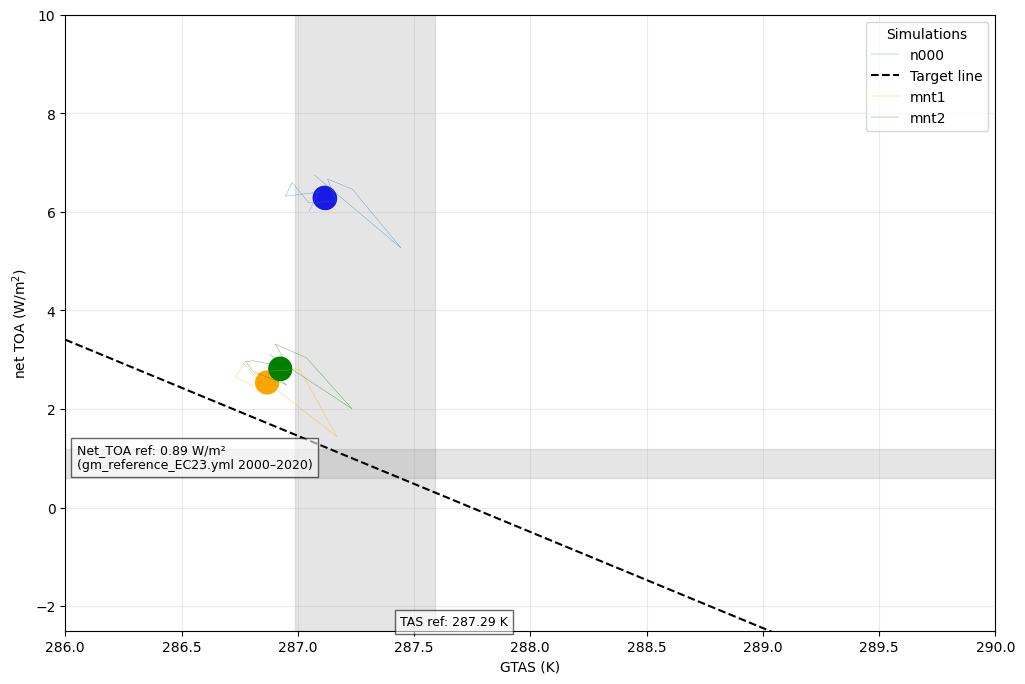

In [22]:
fig

### positive deltaT

In [23]:
#exp = 't7m5'
#exp = 'TN15'
exp = 'mnt3'
cart = f'/ec/res4/scratch/ecme3038/ece4/{exp}/output/oifs/'
filz = cart + f'{exp}_atm_cmip6_1m_*.nc'

In [24]:
gigi4 = xr.open_mfdataset(filz)

/etc/ecmwf/ssd/ssd1/tmpdirs/ecme3038.2266773.20251110_073539.767/ipykernel_3918664/551238400.py:1: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  gigi4 = xr.open_mfdataset(filz)


In [25]:
gigi4 = gigi4.rename({'time_counter': 'time'})

In [26]:
# Force lat into memory, drop Dask chunking
gigi4 = gigi4.assign_coords(lat=gigi4.lat.compute())

all_lats = gigi4.lat.groupby('lat').mean()
weights = np.cos(np.deg2rad(all_lats))

gigimean4 = (
    gigi4.groupby('time.year').mean()
        .groupby('lat').mean()
        .weighted(weights).mean('lat')
)

gigimean4 = gigimean4[['rsut', 'rlut', 'rsdt', 'tas']]
gigimean4['toa_net'] = gigimean4.rsdt - gigimean4.rlut - gigimean4.rsut
gigimean4 = gigimean4.compute()

In [27]:
ax.plot(gigimean4.tas, gigimean4.toa_net, color = 'purple', linewidth=0.2, label='mnt3')
running20_tas = gigimean4.tas.rolling(year=20, center=True).mean()
running20_toa = gigimean4.toa_net.rolling(year=20, center=True).mean()
ax.plot(running20_tas, running20_toa, color='purple', linewidth=2.0)

year_min = int(gigimean4.tas.year.min())
year_max = int(gigimean4.tas.year.max())
init_slice = slice(year_min, min(year_min + 9, year_max))
final_slice = slice(max(year_min, year_max - 9), year_max)
init_tas = gigimean4.tas.sel(year=init_slice).mean().item()
init_toa = gigimean4.toa_net.sel(year=init_slice).mean().item()
final_tas = gigimean4.tas.sel(year=final_slice).mean().item()
final_toa = gigimean4.toa_net.sel(year=final_slice).mean().item()
ax.scatter(init_tas, init_toa, s=250, edgecolors="purple", facecolors="none",
           marker="o", linewidth=1.5)
ax.scatter(final_tas, final_toa, s=250, color='purple', edgecolors="purple",
           marker="o", linewidth=1.0)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title="Simulations", loc="best")

# out_dir = "/home/ecme3038/work/ecearth/ecearth4/ECtuner/plots"
# os.makedirs(out_dir, exist_ok=True)
# outname = os.path.join(out_dir, "greg_tu7b_t7m3_4_5.png")
# plt.savefig(outname, dpi=200, bbox_inches="tight")
# print("Saved plot to:", outname)
# plt.close(fig)

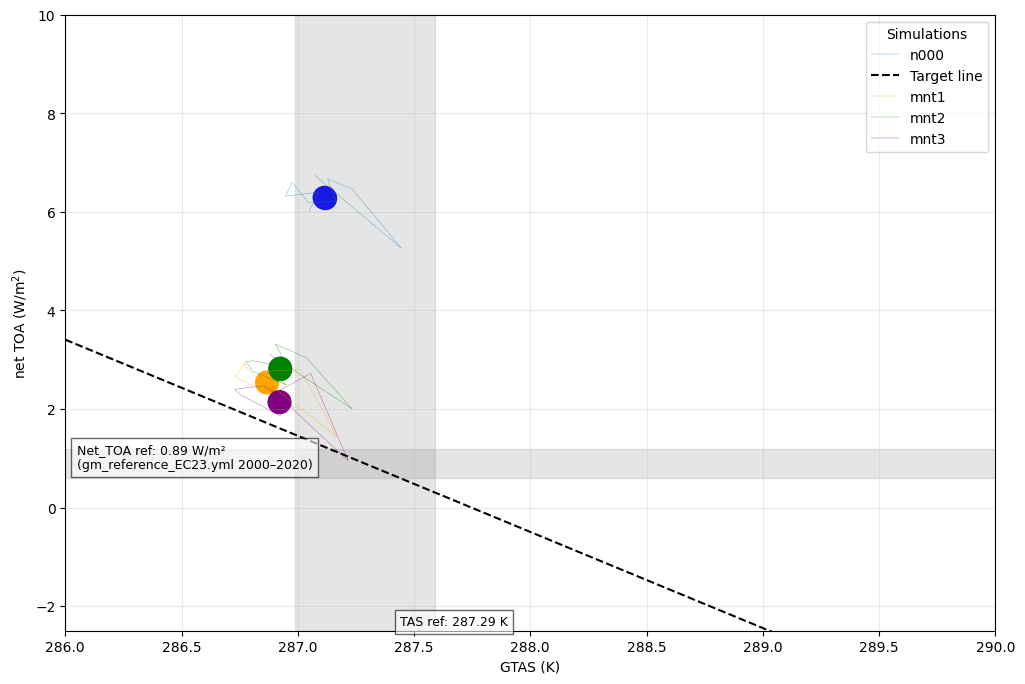

In [28]:
fig

### positive extreme deltaT

In [29]:
#exp = 'T09c'
exp = 'mnt4'
cart = f'/ec/res4/scratch/ecme3038/ece4/{exp}/output/oifs/'
filz = cart + f'{exp}_atm_cmip6_1m_*.nc'

In [30]:
gigi5 = xr.open_mfdataset(filz)

/etc/ecmwf/ssd/ssd1/tmpdirs/ecme3038.2266773.20251110_073539.767/ipykernel_3918664/3634302564.py:1: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  gigi5 = xr.open_mfdataset(filz)


In [31]:
gigi5 = gigi5.rename({'time_counter': 'time'})

In [32]:
# Force lat into memory, drop Dask chunking
gigi5 = gigi5.assign_coords(lat=gigi5.lat.compute())

all_lats = gigi5.lat.groupby('lat').mean()
weights = np.cos(np.deg2rad(all_lats))

gigimean5 = (
    gigi5.groupby('time.year').mean()
        .groupby('lat').mean()
        .weighted(weights).mean('lat')
)

gigimean5 = gigimean5[['rsut', 'rlut', 'rsdt', 'tas']]
gigimean5['toa_net'] = gigimean5.rsdt - gigimean5.rlut - gigimean5.rsut
gigimean5 = gigimean5.compute()

In [33]:
ax.plot(gigimean5.tas, gigimean5.toa_net, color = 'grey', linewidth=0.2, label='mnt4')
running20_tas = gigimean5.tas.rolling(year=20, center=True).mean()
running20_toa = gigimean5.toa_net.rolling(year=20, center=True).mean()
ax.plot(running20_tas, running20_toa, color='grey', linewidth=2.0)

year_min = int(gigimean5.tas.year.min())
year_max = int(gigimean5.tas.year.max())
init_slice = slice(year_min, min(year_min + 9, year_max))
final_slice = slice(max(year_min, year_max - 9), year_max)
init_tas = gigimean5.tas.sel(year=init_slice).mean().item()
init_toa = gigimean5.toa_net.sel(year=init_slice).mean().item()
final_tas = gigimean5.tas.sel(year=final_slice).mean().item()
final_toa = gigimean5.toa_net.sel(year=final_slice).mean().item()
ax.scatter(init_tas, init_toa, s=250, edgecolors="grey", facecolors="none",
           marker="o", linewidth=1.5)
ax.scatter(final_tas, final_toa, s=250, color='grey', edgecolors="grey",
           marker="o", linewidth=1.0)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title="Simulations", loc="best")

# out_dir = "/home/ecme3038/work/ecearth/ecearth4/ECtuner/plots"
# os.makedirs(out_dir, exist_ok=True)
# outname = os.path.join(out_dir, "greg_tu7b_t7m3_4_5.png")
# plt.savefig(outname, dpi=200, bbox_inches="tight")
# print("Saved plot to:", outname)
# plt.close(fig)

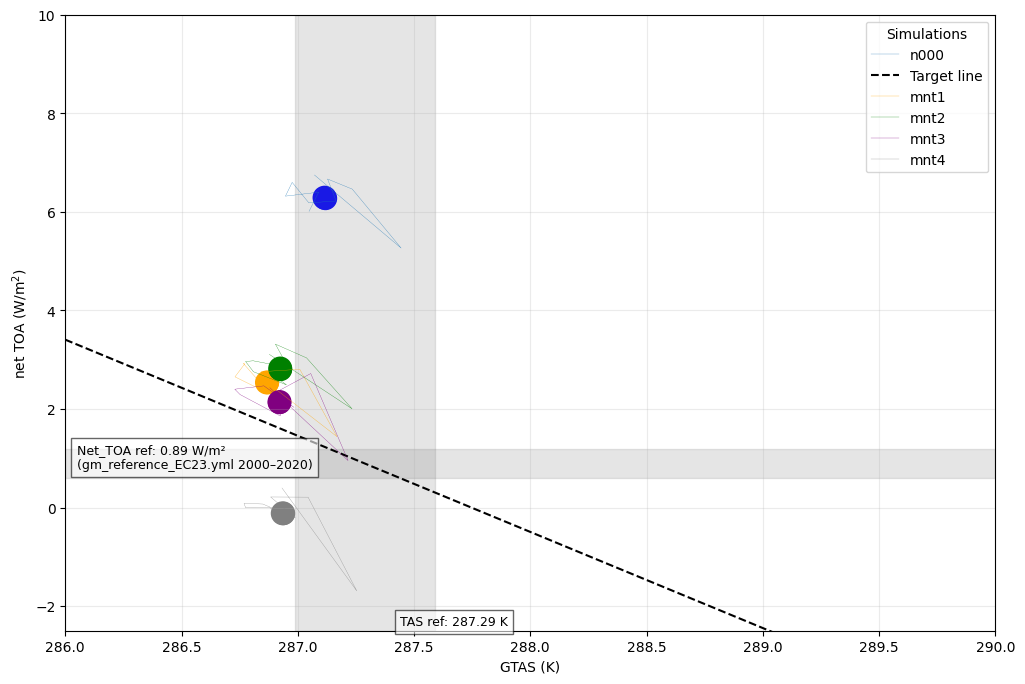

In [34]:
fig

In [42]:

exp = 'mnt5'
cart = f'/ec/res4/scratch/ecme3038/ece4/{exp}/output/oifs/'
filz = cart + f'{exp}_atm_cmip6_1m_*.nc'

In [43]:
gigi6 = xr.open_mfdataset(filz)

/etc/ecmwf/ssd/ssd1/tmpdirs/ecme3038.2266773.20251110_073539.767/ipykernel_3918664/2924534267.py:1: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  gigi6 = xr.open_mfdataset(filz)


In [44]:
gigi6 = gigi6.rename({'time_counter': 'time'})

In [45]:
# Force lat into memory, drop Dask chunking
gigi6 = gigi6.assign_coords(lat=gigi6.lat.compute())

all_lats = gigi6.lat.groupby('lat').mean()
weights = np.cos(np.deg2rad(all_lats))

gigimean6 = (
    gigi6.groupby('time.year').mean()
        .groupby('lat').mean()
        .weighted(weights).mean('lat')
)

gigimean6 = gigimean6[['rsut', 'rlut', 'rsdt', 'tas']]
gigimean6['toa_net'] = gigimean6.rsdt - gigimean6.rlut - gigimean6.rsut
gigimean6 = gigimean6.compute()

In [46]:
ax.plot(gigimean6.tas, gigimean6.toa_net, color = 'red', linewidth=0.2, label='mnt5')
running20_tas = gigimean6.tas.rolling(year=20, center=True).mean()
running20_toa = gigimean6.toa_net.rolling(year=20, center=True).mean()
ax.plot(running20_tas, running20_toa, color='red', linewidth=2.0)

year_min = int(gigimean6.tas.year.min())
year_max = int(gigimean6.tas.year.max())
init_slice = slice(year_min, min(year_min + 9, year_max))
final_slice = slice(max(year_min, year_max - 9), year_max)
init_tas = gigimean6.tas.sel(year=init_slice).mean().item()
init_toa = gigimean6.toa_net.sel(year=init_slice).mean().item()
final_tas = gigimean6.tas.sel(year=final_slice).mean().item()
final_toa = gigimean6.toa_net.sel(year=final_slice).mean().item()
ax.scatter(init_tas, init_toa, s=250, edgecolors="red", facecolors="none",
           marker="o", linewidth=1.5)
ax.scatter(final_tas, final_toa, s=250, color='red', edgecolors="red",
           marker="o", linewidth=1.0)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title="Simulations", loc="best")

# out_dir = "/home/ecme3038/work/ecearth/ecearth4/ECtuner/plots"
# os.makedirs(out_dir, exist_ok=True)
# outname = os.path.join(out_dir, "greg_tu7b_t7m3_4_5.png")
# plt.savefig(outname, dpi=200, bbox_inches="tight")
# print("Saved plot to:", outname)
# plt.close(fig)

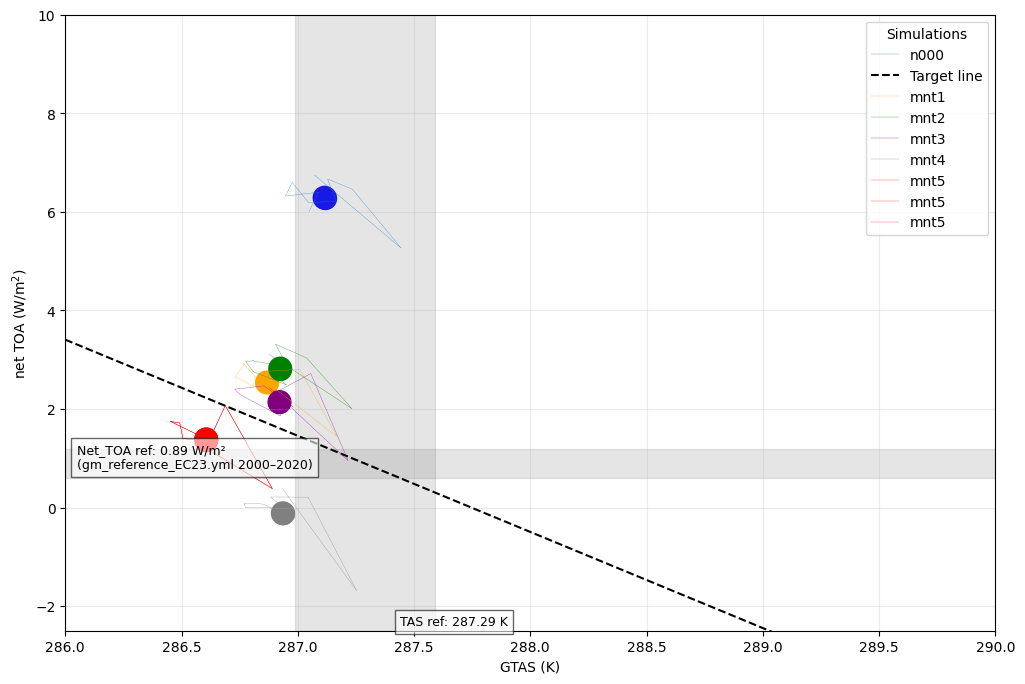

In [47]:
fig

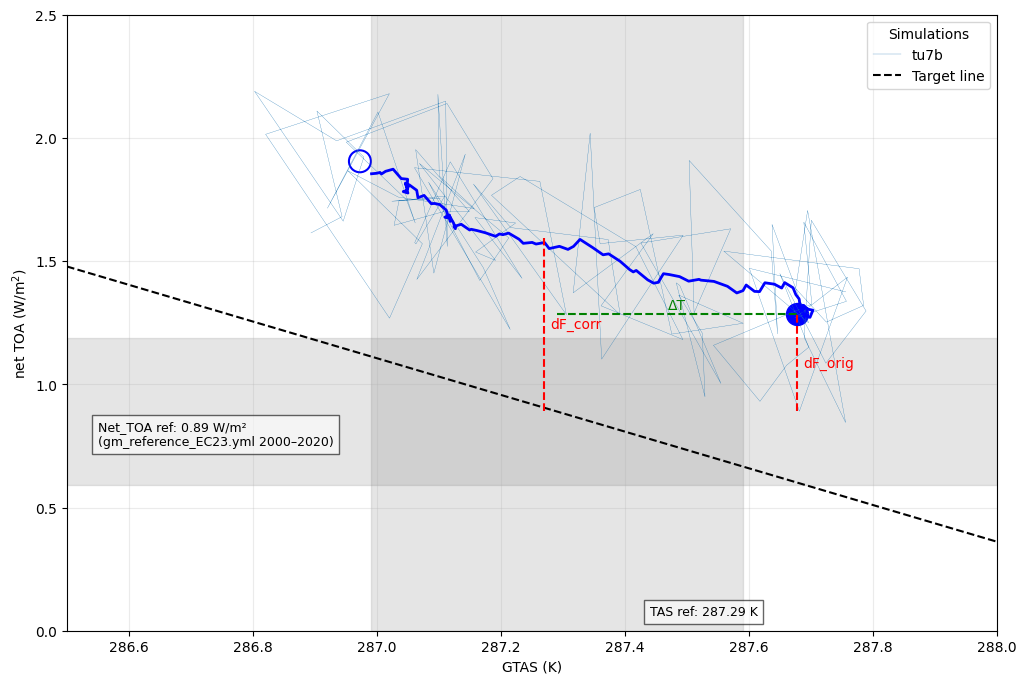

In [37]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(gigimean.tas, gigimean.toa_net, linewidth=0.2, label='tu7b')

# Reference values
tas_clim = 287.29
net_toa_clim = 0.89
dx = dy = 0.3

# Running mean
running20_tas = gigimean.tas.rolling(year=20, center=True).mean()
running20_toa = gigimean.toa_net.rolling(year=20, center=True).mean()
ax.plot(running20_tas, running20_toa, color='blue', linewidth=2.0, linestyle="-")

# --- Marker iniziale/finale ---
ax.set_ylim(0, 2.5)
ax.set_xlim(286.5, 288.0)
year_min = int(gigimean.tas.year.min())
year_max = int(gigimean.tas.year.max())
init_slice = slice(year_min, min(year_min + 9, year_max))
final_slice = slice(max(year_min, year_max - 9), year_max)

init_tas = gigimean.tas.sel(year=init_slice).mean().item()
init_toa = gigimean.toa_net.sel(year=init_slice).mean().item()
final_tas = gigimean.tas.sel(year=final_slice).mean().item()
final_toa = gigimean.toa_net.sel(year=final_slice).mean().item()

ax.scatter(init_tas, init_toa, s=250, edgecolors="blue", facecolors="none",
           marker="o", linewidth=1.5)
ax.scatter(final_tas, final_toa, s=250, color="blue", edgecolors="blue",
           marker="o", linewidth=1.0)

# --- Target line retta (basata su slope del fit) ---
slope, intercept = np.polyfit(gigimean.tas.values, gigimean.toa_net.values, 1)
xmin, xmax = ax.get_xlim()
x_line = np.linspace(xmin, xmax, 200)
y_line = slope * (x_line - tas_clim) + net_toa_clim
ax.plot(x_line, y_line, "k--", label="Target line")

# --- Calcolo centro della simulazione (tu7b) ---
mid_tas = (init_tas + final_tas) / 2
mid_toa = (init_toa + final_toa) / 2

# --- LINEA dF_orig (a destra): dal pallino finale blu al centro banda net_TOA ---
ax.vlines(final_tas, ymin=net_toa_clim, ymax=final_toa, colors='red', linestyles='dashed')
ax.text(final_tas + 0.01, (final_toa + net_toa_clim) / 2, "dF_orig", color='red', va='center')

# --- LINEA ΔT (verde): dal pallino finale blu al centro banda TAS ---
ax.hlines(final_toa, xmin=tas_clim, xmax=final_tas, colors='green', linestyles='dashed')
ax.text((final_tas + tas_clim) / 2, final_toa + 0.02, "ΔT", color='green', ha='center')

# --- LINEA dF_corr (a sinistra): dal centro sim al centro banda net_TOA ---
ax.vlines(tas_clim - 0.02, ymin=net_toa_clim, ymax=mid_toa, colors='red', linestyles='dashed')
ax.text(tas_clim - 0.02 + 0.01, (mid_toa + net_toa_clim) / 2, "dF_corr", color='red', va='center')

# --- Bande di riferimento ---
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
ax.fill_betweenx(np.linspace(ymin, ymax, 200),
                 tas_clim - dx, tas_clim + dx, color="grey", alpha=0.2)
ax.fill_between(np.linspace(xmin, xmax, 200),
                net_toa_clim - dy, net_toa_clim + dy, color="grey", alpha=0.2)

# Etichette bande
x_text_tas = tas_clim + dx / 2
y_text_tas = ymin + 0.05  
ax.text(x_text_tas, y_text_tas, f"TAS ref: {tas_clim:.2f} K",
        va="bottom", ha="left", fontsize=9,
        bbox=dict(facecolor="white", alpha=0.6))

x_text_toa = xmin + 0.05
y_text_toa = net_toa_clim - dy / 2
ax.text(x_text_toa, y_text_toa,
        f"Net_TOA ref: {net_toa_clim:.2f} W/m²\n(gm_reference_EC23.yml 2000–2020)",
        va="bottom", ha="left", fontsize=9,
        bbox=dict(facecolor="white", alpha=0.6))

ax.set_xlabel("GTAS (K)")
ax.set_ylabel("net TOA (W/m$^2$)")
ax.grid(alpha=0.25)
ax.legend(title="Simulations", loc="best")
plt.show()

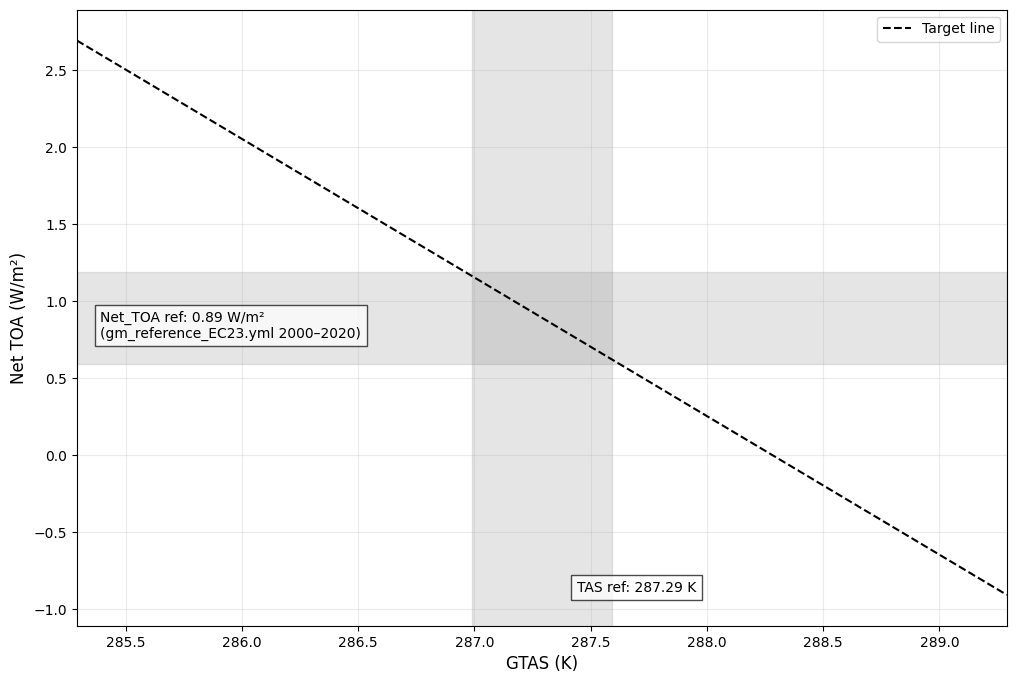

In [39]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 8))

# --- Valori di riferimento ---
tas_clim = 287.29  # K
net_toa_clim = 0.89  # W/m²
dx = dy = 0.3

# --- Definizione del dominio del grafico ---
xmin, xmax = tas_clim - 2, tas_clim + 2
ymin, ymax = net_toa_clim - 2, net_toa_clim + 2

# --- Pendenza ipotetica della linea target (Gregory slope) ---
slope = -0.9  # esempio: TOA netto vs Tsurf (W/m² per K)
# intercept regolato in modo che la linea passi per il punto target
intercept = net_toa_clim - slope * tas_clim  

# --- Linea target obliqua ---
x_line = np.linspace(xmin, xmax, 200)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, "k--", label="Target line")

# --- Bande di riferimento ---
ax.fill_betweenx(np.linspace(ymin, ymax, 200),
                 tas_clim - dx, tas_clim + dx, color="grey", alpha=0.2)
ax.fill_between(np.linspace(xmin, xmax, 200),
                net_toa_clim - dy, net_toa_clim + dy, color="grey", alpha=0.2)

# --- Testo di riferimento ---
x_text_tas = tas_clim + dx / 2
y_text_tas = ymin + 0.2
ax.text(x_text_tas, y_text_tas,
        f"TAS ref: {tas_clim:.2f} K",
        va="bottom", ha="left", fontsize=10,
        bbox=dict(facecolor="white", alpha=0.7))

x_text_toa = xmin + 0.1
y_text_toa = net_toa_clim - dy / 2
ax.text(x_text_toa, y_text_toa,
        f"Net_TOA ref: {net_toa_clim:.2f} W/m²\n(gm_reference_EC23.yml 2000–2020)",
        va="bottom", ha="left", fontsize=10,
        bbox=dict(facecolor="white", alpha=0.7))

# --- Etichette e stile ---
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_xlabel("GTAS (K)", fontsize=12)
ax.set_ylabel("Net TOA (W/m²)", fontsize=12)
ax.grid(alpha=0.25)
ax.legend()
plt.show()

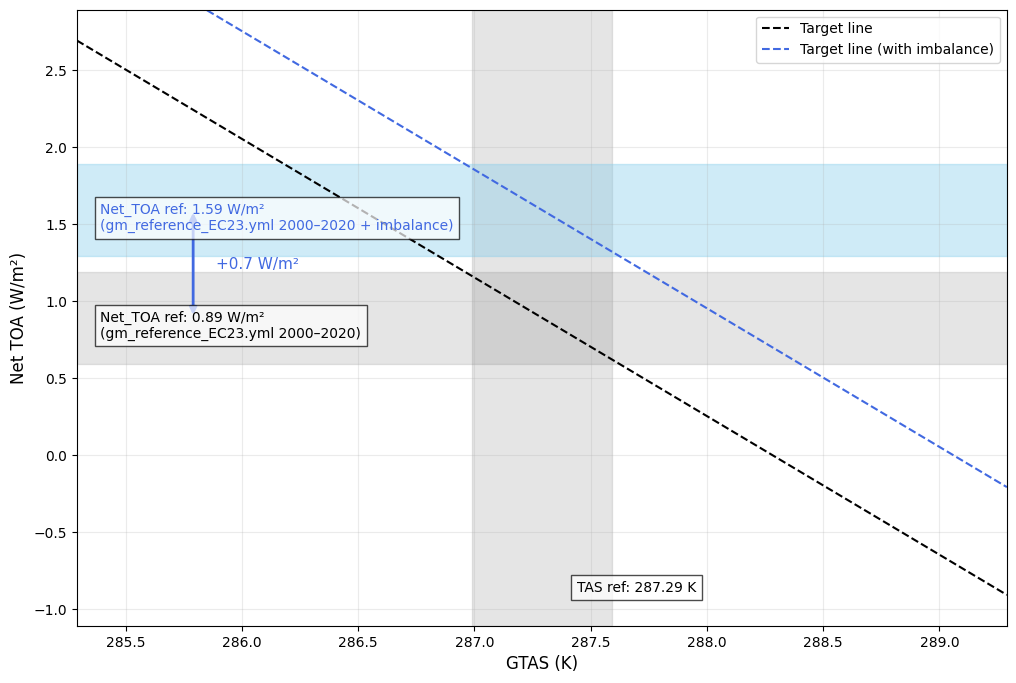

In [2]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 8))

# --- Valori di riferimento ---
tas_clim = 287.29  # K
net_toa_clim = 0.89  # W/m²
imbalance = 0.7  # W/m²
dx = dy = 0.3

# --- Definizione del dominio del grafico ---
xmin, xmax = tas_clim - 2, tas_clim + 2
ymin, ymax = net_toa_clim - 2, net_toa_clim + 2

# --- Pendenza ipotetica della linea target (Gregory slope) ---
slope = -0.9  # TOA netto vs Tsurf (W/m² per K)
intercept = net_toa_clim - slope * tas_clim

# --- Linea target originale ---
x_line = np.linspace(xmin, xmax, 200)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, "k--", label="Target line")

# --- Bande di riferimento ---
# Banda temperatura
ax.fill_betweenx(np.linspace(ymin, ymax, 200),
                 tas_clim - dx, tas_clim + dx, color="grey", alpha=0.2)

# Banda net TOA originale
ax.fill_between(np.linspace(xmin, xmax, 200),
                net_toa_clim - dy, net_toa_clim + dy, color="grey", alpha=0.2)

# --- Nuova banda net TOA + imbalance ---
ax.fill_between(np.linspace(xmin, xmax, 200),
                (net_toa_clim + imbalance) - dy,
                (net_toa_clim + imbalance) + dy,
                color="skyblue", alpha=0.4)

# --- Nuova linea tratteggiata (target con imbalance) ---
# Intersezione con banda temperatura = punto a tas_clim
y_new_line = slope * x_line + intercept + imbalance
ax.plot(x_line, y_new_line, "--", color="royalblue", label="Target line (with imbalance)")

# --- Freccia di spostamento ---
x_arrow = xmin + 0.5
y_arrow_start = net_toa_clim
y_arrow_end = net_toa_clim + imbalance
ax.annotate("", xy=(x_arrow, y_arrow_end), xytext=(x_arrow, y_arrow_start),
            arrowprops=dict(arrowstyle="<|-|>", lw=2, color="royalblue"))
ax.text(x_arrow + 0.1, (y_arrow_start + y_arrow_end) / 2,
        f"+{imbalance:.1f} W/m²", color="royalblue", fontsize=11, va="center")

# --- Testo di riferimento ---
x_text_tas = tas_clim + dx / 2
y_text_tas = ymin + 0.2
ax.text(x_text_tas, y_text_tas,
        f"TAS ref: {tas_clim:.2f} K",
        va="bottom", ha="left", fontsize=10,
        bbox=dict(facecolor="white", alpha=0.7))

x_text_toa = xmin + 0.1
y_text_toa = net_toa_clim - dy / 2
ax.text(x_text_toa, y_text_toa,
        f"Net_TOA ref: {net_toa_clim:.2f} W/m²\n(gm_reference_EC23.yml 2000–2020)",
        va="bottom", ha="left", fontsize=10,
        bbox=dict(facecolor="white", alpha=0.7))

# --- Testo per la nuova banda con imbalance ---
y_text_toa_new = (net_toa_clim + imbalance) - dy / 2
ax.text(x_text_toa, y_text_toa_new,
        f"Net_TOA ref: {net_toa_clim + imbalance:.2f} W/m²\n(gm_reference_EC23.yml 2000–2020 + imbalance)",
        va="bottom", ha="left", fontsize=10,
        bbox=dict(facecolor="white", alpha=0.7), color="royalblue")

# --- Etichette e stile ---
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_xlabel("GTAS (K)", fontsize=12)
ax.set_ylabel("Net TOA (W/m²)", fontsize=12)
ax.grid(alpha=0.25)
ax.legend()
plt.show()

In [35]:
#to adjust cause the computation of net_sfc is not correct. furthermore  is better to do regridding with CDO


# import os
# import xarray as xr
# import xesmf as xe

# exp = 't7m3'
# # --- Parametri ---
# oifs_path = f"/ec/res4/scratch/ccff/ece4/{exp}/output/oifs"
# save_path = f"/ec/res4/hpcperm/ecme3038/ecearth/ecearth4/analysis/{exp}/net_sfc_r/"
# os.makedirs(save_path, exist_ok=True)

# # --- Carica i dati OIFS ---
# ds = xr.open_mfdataset(
#     os.path.join(oifs_path, "*.nc"),
#     combine="by_coords",
#     parallel=True
# )[["rsns", "rlns", "hfss", "hfls"]]

# # --- Calcola net_sfc ---
# net_sfc = ds.rsns + ds.rlns - (ds.hfss + ds.hfls)
# net_sfc.name = "net_sfc"
# net_sfc.attrs["long_name"] = "Net Surface Energy Flux"
# net_sfc.attrs["units"] = "W/m2"

# # --- Carica la griglia oceano ---
# # Assumiamo di avere un dataset 'ds_ocean' con lat/lon della griglia oceano
# # ds_ocean = xr.open_dataset("ocean_grid.nc")

# # --- Rigriglia ---
# ds_ocean = xr.open_dataset("tu7b_oce_1m_T_2040-2040.nc")
# grid_out = xr.Dataset({
#     'lat': ds_ocean['nav_lat_grid_T'],
#     'lon': ds_ocean['nav_lon_grid_T']
# })
# regridder = xe.Regridder(net_sfc, grid_out, "bilinear", reuse_weights=True)
# net_sfc_ocean = regridder(net_sfc)

# # --- Salva ---
# net_sfc_ocean.to_netcdf(os.path.join(save_path, f"net_sfc_{exp}_oce.nc"))